# Model diagnostics & interpretation cheat sheet

A toolkit for the ten minutes *after* you get a number.

**What's in here**
- Ridge with lag features, chronological split; predicted vs actual for one week
- Error distribution and error by hour / day-of-week / month; the worst hours
- Rolling RMSE over time (regime deterioration - shown on a price model)
- Train vs test gap; coefficient stability across years
- Multicollinearity: correlation matrix, VIF by hand, Ridge vs OLS under collinearity
- `permutation_importance`; partial dependence by hand
- Residual autocorrelation and what it tells you
- A "suspiciously good result" detector: two leaked-feature examples
- How to critique a model in five minutes

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

pd.set_option("display.width", 120); pd.set_option("display.max_columns", 30)
np.set_printoptions(precision=4, suppress=True)

df = pd.read_csv("../data/hourly_power_clean.csv", parse_dates=["time"]).sort_values("time").reset_index(drop=True)
df["hour"]    = df["time"].dt.hour
df["dow"]     = df["time"].dt.dayofweek
df["month"]   = df["time"].dt.month
df["weekend"] = (df["dow"] >= 5).astype(int)
df["hdd"]     = np.clip(15 - df["temp_c"], 0, None)      # heating degrees
df["cdd"]     = np.clip(df["temp_c"] - 22, 0, None)      # cooling degrees
print(df.shape); df.head(3)

(17520, 12)


,time,consumption_mwh,temp_c,wind_ms,solar_wm2,price_eur_mwh,hour,dow,month,weekend,hdd,cdd
0,2022-01-01 00:00:00+00:00,26858.4,0.11,7.00,0.0,81.83,0,5,1,1,14.89,0.0
1,2022-01-01 01:00:00+00:00,26177.8,-0.18,6.61,0.0,88.21,1,5,1,1,15.18,0.0
2,2022-01-01 02:00:00+00:00,26229.4,-1.11,7.14,0.0,84.71,2,5,1,1,16.11,0.0


## Model: one-hour-ahead consumption with lags

Features at t use consumption up to t-1 only. `shift(1).rolling(24)` - the shift comes *first*, so the window is t-24..t-1.

In [2]:
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

d = df.copy()
c = d["consumption_mwh"]
d["lag1"], d["lag24"], d["lag168"] = c.shift(1), c.shift(24), c.shift(168)
d["roll24"] = c.shift(1).rolling(24).mean()
hour_d = pd.get_dummies(d["hour"], prefix="h", dtype=float)
d = pd.concat([d, hour_d], axis=1).dropna().reset_index(drop=True)
feats = ["lag1", "lag24", "lag168", "roll24", "temp_c", "hdd", "cdd", "weekend"] + list(hour_d.columns)
split = int(len(d) * 0.8)
tr, te = d.iloc[:split], d.iloc[split:].copy()

model = make_pipeline(StandardScaler(), Ridge(alpha=1.0)).fit(tr[feats], tr["consumption_mwh"])
te["pred"] = model.predict(te[feats])
te["err"] = te["consumption_mwh"] - te["pred"]
tr_pred = model.predict(tr[feats])
naive = te["lag1"]                                    # naive: last hour's value

def m(y, p): return {"rmse": root_mean_squared_error(y, p), "mae": mean_absolute_error(y, p), "r2": r2_score(y, p)}
pd.DataFrame({"train": m(tr["consumption_mwh"], tr_pred), "test": m(te["consumption_mwh"], te["pred"]),
              "naive lag1 (test)": m(te["consumption_mwh"], naive)}).round(3)

,train,test,naive lag1 (test)
rmse,504.152,512.779,1522.052
mae,395.796,401.599,1242.213
r2,0.986,0.983,0.850


**Interview check:** "R² of 0.98 - great model?" One hour ahead, the naive "same as last hour" already gets R² 0.85. The honest headline is the RMSE *relative to naive* (here roughly a 3x reduction), not the R². Also: train and test RMSE are close, so no overfitting signal.

## Predicted vs actual, one week

Always look at a plot of a few days. Systematic lag (prediction trailing the actual) is the signature of a model leaning on lag1.

,time,consumption_mwh,pred,err
14553,2023-09-06 09:00:00+00:00,31573.0,30729.0,845.0
14554,2023-09-06 10:00:00+00:00,30937.0,31047.0,-110.0
14555,2023-09-06 11:00:00+00:00,31022.0,30355.0,667.0
14556,2023-09-06 12:00:00+00:00,30482.0,30329.0,154.0
14557,2023-09-06 13:00:00+00:00,30115.0,29577.0,538.0
14558,2023-09-06 14:00:00+00:00,29795.0,29494.0,301.0


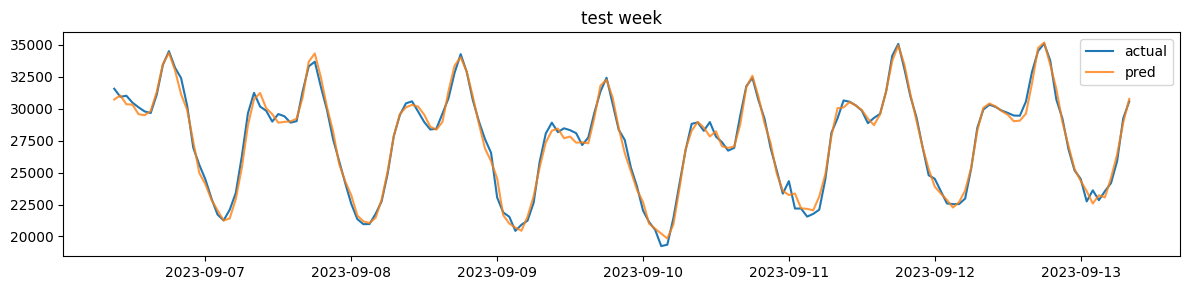

In [3]:
wk = te.iloc[24*7*4: 24*7*5]
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(wk["time"], wk["consumption_mwh"], label="actual"); ax.plot(wk["time"], wk["pred"], label="pred", alpha=.8)
ax.legend(); ax.set_title("test week"); plt.tight_layout()
wk[["time", "consumption_mwh", "pred", "err"]].head(6).round(0)

## Error distribution

`describe` plus tail quantiles. Compare the standard deviation with the RMSE: if they differ, there is bias. Look at the tails - a 1% tail 5x the standard deviation means a few hours dominate.

In [4]:
e = te["err"]
print(e.describe().round(0).to_dict())
print("quantiles:", e.quantile([0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999]).round(0).to_dict())
print(f"bias={e.mean():.1f}  std={e.std():.1f}  rmse={np.sqrt((e**2).mean()):.1f}")

{'count': 3471.0, 'mean': -51.0, 'std': 510.0, 'min': -1948.0, '25%': -380.0, '50%': -59.0, '75%': 280.0, 'max': 2435.0}
quantiles: {0.001: -1835.0, 0.01: -1272.0, 0.05: -867.0, 0.5: -59.0, 0.95: 766.0, 0.99: 1156.0, 0.999: 1675.0}
bias=-51.3  std=510.3  rmse=512.8


## Error by hour / day-of-week / month

Mean error (bias) and spread per group. A non-zero mean in some group is a missing feature or interaction.

In [5]:
print(te.groupby("hour")["err"].agg(["mean", "std"]).round(0).T.to_string())

hour     0      1      2      3      4      5      6      7      8      9      10     11     12     13     14     15     16     17     18     19     20     21     22     23
mean  -37.0  -38.0  -26.0 -107.0  -86.0   -9.0  -90.0   -7.0  -68.0  -42.0  -99.0  -28.0  -63.0  -27.0  -75.0  -93.0   -2.0   -7.0  -34.0   27.0  -71.0  -11.0 -167.0  -72.0
std   853.0  511.0  480.0  500.0  528.0  493.0  465.0  486.0  484.0  517.0  497.0  488.0  460.0  493.0  465.0  483.0  507.0  503.0  421.0  493.0  506.0  531.0  492.0  449.0


In [6]:
print(te.groupby("dow")["err"].agg(["mean", "std"]).round(0).T.to_string())
print()
print(te.groupby("month")["err"].agg(["mean", "std", "count"]).round(0).T.to_string())

dow       0      1      2      3      4      5      6
mean  -42.0  -13.0  -27.0  -85.0  -91.0  -91.0   -7.0
std   564.0  479.0  480.0  476.0  487.0  588.0  481.0

month     8      9      10     11     12
mean   -13.0  -29.0  -12.0  -68.0 -124.0
std    498.0  509.0  513.0  502.0  519.0
count  543.0  720.0  744.0  720.0  744.0


## The worst hours

Sort by absolute error and look at everything about those rows. Do they share a time of day, a weather state, a price spike, a data gap?

In [7]:
worst = te.loc[te["err"].abs().sort_values(ascending=False).index[:10], ["time", "consumption_mwh", "pred", "err", "temp_c", "price_eur_mwh", "lag1"]]
worst["jump_from_lag1"] = worst["consumption_mwh"] - worst["lag1"]
worst.round(0)

,time,consumption_mwh,pred,err,temp_c,price_eur_mwh,lag1,jump_from_lag1
15000,2023-09-25 00:00:00+00:00,25757.0,23321.0,2435.0,11.0,69.0,23490.0,2266.0
15168,2023-10-02 00:00:00+00:00,24974.0,22821.0,2152.0,10.0,62.0,22672.0,2302.0
15120,2023-09-30 00:00:00+00:00,22290.0,24239.0,-1948.0,9.0,20.0,25758.0,-3467.0
14952,2023-09-23 00:00:00+00:00,20460.0,22397.0,-1937.0,12.0,22.0,23677.0,-3217.0
16128,2023-11-11 00:00:00+00:00,24964.0,26886.0,-1922.0,2.0,54.0,28288.0,-3324.0
14784,2023-09-16 00:00:00+00:00,22337.0,24219.0,-1882.0,8.0,35.0,25403.0,-3066.0
15960,2023-11-04 00:00:00+00:00,24388.0,26170.0,-1782.0,6.0,42.0,28040.0,-3652.0
14832,2023-09-18 00:00:00+00:00,25221.0,23453.0,1768.0,9.0,56.0,23321.0,1900.0
15288,2023-10-07 00:00:00+00:00,22484.0,24235.0,-1750.0,10.0,69.0,25882.0,-3397.0
14925,2023-09-21 21:00:00+00:00,30754.0,29049.0,1705.0,14.0,92.0,30846.0,-92.0


Every one of the worst rows is at **00:00**, and the dates are Saturdays and Mondays. The `jump_from_lag1` column is +/-2,000-3,400 MWh - that is the weekend level shift switching on and off at midnight. The model leans on `lag1` and only partly on the `weekend` dummy, so it under-reacts at the transition. Confirm with a group comparison, then think about the fix (an interaction `weekend x hour0`, a "weekend changes at this hour" flag, or modelling the *change* from lag1 instead of the level).

In [8]:
te["boundary"] = (te["hour"] == 0) & te["dow"].isin([0, 5])          # Monday / Saturday midnight
te.groupby("boundary")["err"].agg(["mean", "std", "count", lambda e: e.abs().max()]).round(0).rename(columns={"<lambda_0>": "max_abs"})

,mean,std,count,max_abs
boundary,,,,
False,-51.0,489.0,3430,1705.0
True,-102.0,1434.0,41,2435.0


Hour-0 std in the by-hour table above (850 vs ~500 elsewhere) already pointed at this; the worst-rows table made it obvious. That is the workflow: aggregate table -> anomaly -> look at rows -> hypothesis -> confirm with a targeted group.

Compare the worst hours' properties with the average test hour too: cold? price spikes? big hour-to-hour jumps?

In [9]:
top = te["err"].abs() > te["err"].abs().quantile(0.99)
pd.DataFrame({"worst 1%": te.loc[top, ["temp_c", "price_eur_mwh", "hour", "weekend"]].mean(),
              "all test": te[["temp_c", "price_eur_mwh", "hour", "weekend"]].mean()}).round(2).T

,temp_c,price_eur_mwh,hour,weekend
worst 1%,9.67,69.82,6.77,0.43
all test,10.00,83.29,11.52,0.29


## Rolling RMSE over time - regime deterioration

The consumption process here is stable, so we switch to a *price* model to show what a regime shift looks like: train on 2022 (gas spike), predict 2023. Features: residual load proxies and price lags.

train RMSE: 18.0  test RMSE: 18.5


month,1,2,3,4,5,6,7,8,9,10,11,12
mean,-6.3,-8.0,-10.4,-8.0,-3.5,-0.7,-2.1,-3.7,-3.3,-5.7,-9.3,-9.0
std,15.5,14.3,17.7,15.1,14.3,19.0,19.7,20.2,20.1,15.4,15.4,18.9


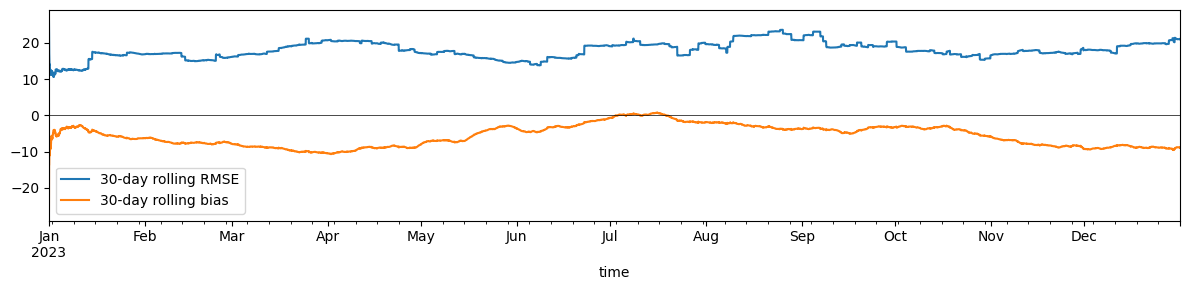

In [10]:
p = df.copy()
p["price_lag1"], p["price_lag24"] = p["price_eur_mwh"].shift(1), p["price_eur_mwh"].shift(24)
p["price_roll168"] = p["price_eur_mwh"].shift(1).rolling(168).mean()
p = p.dropna().reset_index(drop=True)
pf = ["consumption_mwh", "wind_ms", "solar_wm2", "price_lag1", "price_lag24", "price_roll168", "hour", "weekend"]
ptr = p[p["time"] < "2023-01-01"]; pte = p[p["time"] >= "2023-01-01"].copy()
pm = make_pipeline(StandardScaler(), Ridge(alpha=1)).fit(ptr[pf], ptr["price_eur_mwh"])
pte["pred"] = pm.predict(pte[pf]); pte["err"] = pte["price_eur_mwh"] - pte["pred"]
print("train RMSE:", round(root_mean_squared_error(ptr["price_eur_mwh"], pm.predict(ptr[pf])), 1),
      " test RMSE:", round(root_mean_squared_error(pte["price_eur_mwh"], pte["pred"]), 1))

roll = pte.set_index("time")["err"]
rolling_rmse = np.sqrt((roll**2).rolling("30D").mean())
rolling_bias = roll.rolling("30D").mean()
fig, ax = plt.subplots(figsize=(12, 3))
rolling_rmse.plot(ax=ax, label="30-day rolling RMSE"); rolling_bias.plot(ax=ax, label="30-day rolling bias"); ax.axhline(0, c="k", lw=.5); ax.legend(); plt.tight_layout()
pte.groupby("month")["err"].agg(["mean", "std"]).round(1).T

**Interview check:** "Test error is worse than train error - overfitting?" Not necessarily. Here train and test RMSE are close, but the *bias* is persistently negative in 2023 (the model over-predicts: the gas-driven price level fell and nothing in the features carries the gas price), and it is largest in winter. That is *drift* from a missing driver, not variance. Overfitting shows as train error far below test error with no time pattern in the residuals. The rolling-bias line is the tool that separates the two.

## Coefficient stability across periods

Fit the same specification on each year and compare. Coefficients that flip sign or change by multiples are not describing a stable relationship - either the feature is collinear with another, or the relationship drifts.

In [11]:
core = ["lag1", "lag24", "lag168", "roll24", "temp_c", "hdd", "cdd", "weekend"]
def fit_coefs(frame):
    mm = make_pipeline(StandardScaler(), Ridge(alpha=1)).fit(frame[core], frame["consumption_mwh"])
    return pd.Series(mm[-1].coef_, index=core)
stab = pd.DataFrame({"2022": fit_coefs(d[d["time"] < "2023-01-01"]),
                     "2023": fit_coefs(d[d["time"] >= "2023-01-01"]),
                     "all":  fit_coefs(d)})
stab["rel_change"] = ((stab["2023"] - stab["2022"]) / stab["all"].abs()).round(2)
stab.round(1)

,2022,2023,all,rel_change
lag1,1717.9,1672.8,1697.6,-0.0
lag24,1496.6,1591.7,1539.6,0.1
lag168,1189.6,1078.9,1136.5,-0.1
roll24,-795.3,-725.9,-756.4,0.1
temp_c,78.6,-24.6,33.5,-3.1
hdd,821.1,677.4,751.8,-0.2
cdd,6.6,23.3,14.0,1.2
weekend,-452.7,-435.1,-442.5,0.0


`temp_c` flips sign between years while `hdd` stays large and positive: the two are near-duplicates (corr -0.97), so their individual coefficients are not identified - only their sum matters. The lags and `weekend` are stable. **Interview check:** "The temperature coefficient changed sign - has the physics changed?" No: it is collinearity. Check the VIF before interpreting any single coefficient.

## Multicollinearity

Start with the correlation matrix of the features. Then VIF (variance inflation factor) by hand: regress each feature on all the others; VIF = 1 / (1 - R²). VIF > 10 means the coefficient's variance is inflated tenfold; VIF > 100 means the coefficient is essentially not identified individually.

In [12]:
d[core].corr().round(2)

,lag1,lag24,lag168,roll24,temp_c,hdd,cdd,weekend
lag1,1.00,0.86,0.87,0.49,-0.22,0.26,0.01,-0.22
lag24,0.86,1.00,0.90,0.49,-0.19,0.23,0.02,-0.07
lag168,0.87,0.90,1.00,0.43,-0.15,0.19,0.01,-0.22
roll24,0.49,0.49,0.43,1.00,-0.81,0.82,-0.12,-0.28
temp_c,-0.22,-0.19,-0.15,-0.81,1.00,-0.97,0.24,-0.02
hdd,0.26,0.23,0.19,0.82,-0.97,1.00,-0.12,0.03
cdd,0.01,0.02,0.01,-0.12,0.24,-0.12,1.00,0.04
weekend,-0.22,-0.07,-0.22,-0.28,-0.02,0.03,0.04,1.00


In [13]:
def vif_table(frame, cols):
    out = {}
    for col in cols:
        others = [c for c in cols if c != col]
        r2 = LinearRegression().fit(frame[others], frame[col]).score(frame[others], frame[col])
        out[col] = 1 / (1 - r2) if r2 < 1 else np.inf
    return pd.Series(out, name="VIF").sort_values(ascending=False)
vif_table(tr, core).round(1)

temp_c     23.8
hdd        23.3
lag24       9.1
roll24      8.4
lag168      7.3
lag1        5.3
weekend     2.0
cdd         1.4
Name: VIF, dtype: float64

Two collinear clusters: `temp_c`/`hdd` (VIF ~24) and the three lags plus `roll24` (pairwise correlations 0.86-0.90). **What collinearity does to coefficients:** OLS spreads a shared effect across the cluster in an unstable way; Ridge shrinks toward sharing it evenly. Drop `roll24` and watch `lag24`, `hdd` and `temp_c` all move - features that were not dropped.

In [14]:
def coefs(model, cols):
    mm = make_pipeline(StandardScaler(), model).fit(tr[cols], tr["consumption_mwh"])
    return pd.Series(mm[-1].coef_, index=cols)
c_ols_full = coefs(LinearRegression(), core)
c_rdg_full = coefs(Ridge(alpha=50), core)
c_ols_noroll = coefs(LinearRegression(), [c for c in core if c != "roll24"])
pd.DataFrame({"OLS": c_ols_full, "Ridge(50)": c_rdg_full, "OLS w/o roll24": c_ols_noroll}).round(0)

,OLS,Ridge(50),OLS w/o roll24
cdd,11.0,17.0,-5.0
hdd,824.0,750.0,496.0
lag1,1744.0,1738.0,1764.0
lag168,1109.0,1132.0,1314.0
lag24,1586.0,1551.0,1140.0
roll24,-818.0,-766.0,NaN
temp_c,56.0,20.0,363.0
weekend,-459.0,-441.0,-206.0


Predictions barely change while coefficients do - collinearity hurts *interpretation*, not necessarily *prediction*. **Interview check:** "hdd has a large positive coefficient and temp_c a small positive one - so does warmer weather increase demand?" Read them together: the marginal effect of temperature below 15C is (temp coef - hdd coef); individual signs are not meaningful when features are functions of each other.

## Permutation importance

Shuffle one feature in the *test* set, refit nothing, measure the metric drop. Correlated features share importance (shuffling one, the model still gets the information from the other), so low permutation importance does not mean "useless".

In [15]:
from sklearn.inspection import permutation_importance
pi = permutation_importance(model, te[feats], te["consumption_mwh"], n_repeats=5, random_state=0, scoring="neg_root_mean_squared_error")
imp = pd.Series(pi.importances_mean, index=feats).sort_values(ascending=False)
print("RMSE increase when shuffled (top 8):")
print(imp.head(8).round(0).to_string())

RMSE increase when shuffled (top 8):
lag1    3402.0
h_17     593.0
hdd      441.0
h_18     414.0
h_1      353.0
h_16     324.0
h_2      306.0
h_3      291.0


## Partial dependence by hand

Hold every feature at its median, sweep one feature over its range, predict. For engineered features that depend on the swept one (hdd, cdd depend on temp), recompute them - otherwise the curve is nonsense.

In [16]:
base = te[feats].median()
grid = np.linspace(te["temp_c"].min(), te["temp_c"].max(), 9)
rows = []
for T in grid:
    row = base.copy(); row["temp_c"] = T; row["hdd"] = max(15 - T, 0); row["cdd"] = max(T - 22, 0)
    rows.append(row)
pdp = pd.DataFrame(rows)
pd.DataFrame({"temp_c": grid.round(1), "pred_mwh": model.predict(pdp).round(0)}).T

,0,1,2,3,4,5,6,7,8
temp_c,-2.6,0.8,4.2,7.7,11.1,14.6,18.0,21.5,24.9
pred_mwh,31334.0,30862.0,30389.0,29917.0,29444.0,28971.0,28891.0,28867.0,28936.0


**Pitfall:** the partial-dependence effect of temperature looks tiny here because `lag1` is held fixed at its median. With lag features the model attributes most variation to the lag; the temperature effect shows up over 24 hours, not one. Ask "at which horizon does this feature matter?".

## Residual autocorrelation

Residuals should be white noise. A lag-1 autocorrelation well above zero says: add a lag (or the noise process has memory the model ignores). Compare the model with and without `lag1`.

In [17]:
def resid_acf(cols, lags=(1, 2, 24)):
    mm = make_pipeline(StandardScaler(), Ridge(alpha=1)).fit(tr[cols], tr["consumption_mwh"])
    r = te["consumption_mwh"] - mm.predict(te[cols])
    return {f"acf{k}": round(r.autocorr(k), 3) for k in lags} | {"rmse": round(np.sqrt((r**2).mean()), 0)}
pd.DataFrame({"with lag1": resid_acf(feats), "without lag1": resid_acf([f for f in feats if f != "lag1"])}).T

,acf1,acf2,acf24,rmse
with lag1,0.120,0.088,0.048,513.0
without lag1,0.789,0.618,0.078,756.0


## Suspiciously-good-result detector

Two realistic leaks. **Leak A:** `rolling(24).mean()` without `shift(1)` - the window includes the current hour. Together with the shifted rolling mean and `lag24`, the target can be recovered *exactly*: 24*(roll_now - roll_shifted) = y_t - y_{t-24}. **Leak B:** a "lag" with `shift(0)`.

In [18]:
leak = d.copy()
leak["roll24_noshift"] = leak["consumption_mwh"].rolling(24).mean()     # includes t
leak["lag0_oops"] = leak["consumption_mwh"].shift(0)                    # is the target
leak = leak.dropna().reset_index(drop=True)
s2 = int(len(leak) * 0.8); ltr, lte = leak.iloc[:s2], leak.iloc[s2:]

def fit_report(cols, label):
    mm = LinearRegression().fit(ltr[cols], ltr["consumption_mwh"])
    pr = mm.predict(lte[cols])
    print(f"{label:28s} test R2={r2_score(lte['consumption_mwh'], pr):.6f}  RMSE={root_mean_squared_error(lte['consumption_mwh'], pr):8.2f}")
    return pd.Series(mm.coef_, index=cols)

honest = fit_report(["lag1", "lag24", "roll24", "temp_c"], "honest")
leakA  = fit_report(["lag1", "lag24", "roll24", "roll24_noshift", "temp_c"], "leak A: rolling w/o shift")
leakB  = fit_report(["lag1", "lag24", "roll24", "lag0_oops", "temp_c"], "leak B: shift(0)")
print()
print(pd.DataFrame({"honest": honest, "leak A": leakA, "leak B": leakB}).round(3))

honest                       test R2=0.913978  RMSE= 1151.62
leak A: rolling w/o shift    test R2=1.000000  RMSE=    0.00
leak B: shift(0)             test R2=1.000000  RMSE=    0.00

                honest  leak A  leak B
lag0_oops          NaN     NaN     1.0
lag1             0.582     0.0     0.0
lag24            0.430     1.0    -0.0
roll24          -0.109   -24.0     0.0
roll24_noshift     NaN    24.0     NaN
temp_c         -33.506    -0.0    -0.0


How you notice, in order of how fast:

1. **RMSE far below the naive baseline** (here 0 vs ~1,150 for the honest model and ~1,500 for naive). One-hour-ahead load does not get predicted to the MWh.
2. **Coefficient signature**: +24 / -24 on two rolling means and +1 on lag24 (leak A); ~1 on one feature and ~0 on the rest (leak B).
3. **Feature audit**: list every feature that is computed from the target column and check the `shift` on each.
4. **Timestamp audit**: for each feature, write down the latest timestamp of raw data it uses. If it is >= the target's timestamp, it is a leak.

## How to critique a model in five minutes

1. **What is the target and the horizon?** Is every feature known at prediction time? (Timestamp audit.)
2. **How was it split?** Chronological? Any preprocessing fit on the full data? Gap when targets overlap?
3. **What is the baseline?** Naive / seasonal naive / mean. Report improvement over it.
4. **Where is it wrong?** Error by hour, day, month, regime; the worst 10 rows.
5. **Is it stable?** Train vs test gap; coefficients by sub-period; rolling RMSE.
6. **Do the coefficients make physical sense?** Signs, magnitudes per standard deviation, collinearity (VIF).
7. **What is left in the residuals?** Autocorrelation, bias by group, heteroskedasticity.
8. **What would I try next, and how would I know it helped?** A single held-out period that nothing above has touched.

## Quick reference

| Task | Call |
|---|---|
| Error by group | `te.groupby("hour")["err"].agg(["mean", "std"])` |
| Worst rows | `te.loc[te["err"].abs().nlargest(10).index]` |
| Rolling RMSE | `np.sqrt((err**2).rolling("30D").mean())` on a time index |
| VIF | `1 / (1 - LinearRegression().fit(X_others, x).score(X_others, x))` |
| Residual ACF | `resid.autocorr(k)` |
| Permutation importance | `permutation_importance(m, X_te, y_te, scoring="neg_root_mean_squared_error")` |
| Leak signature | test RMSE << naive; one coef ~1; `rolling()` without `shift(1)` |